In [166]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from scipy.cluster import hierarchy
from scipy.signal import butter, filtfilt, freqz
from scipy import signal
import matplotlib as mpl
from matplotlib.pyplot import cm
import random
from scipy.stats import sem, zscore
import time
import h5py
import ants
import nibabel as nib
import matplotlib
from scipy.ndimage import gaussian_filter1d
import pickle
from skimage import io
import glob
from scipy.ndimage import uniform_filter
from itertools import islice

In [2]:
fly_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'


In [4]:
for x in sorted(os.listdir(later_dir)):
    print(x)

208_stepsize_100_STA.h5
208_stepsize_10_STA.h5
209_stepsize_100_STA.h5
209_stepsize_10_STA.h5
210_stepsize_100_STA.h5
210_stepsize_10_STA.h5
217_stepsize_100_STA.h5
217_stepsize_10_STA.h5
218_stepsize_100_STA.h5
218_stepsize_10_STA.h5
226_stepsize_100_STA.h5
226_stepsize_10_STA.h5
227_stepsize_100_STA.h5
227_stepsize_10_STA.h5
228_stepsize_100_STA.h5
228_stepsize_10_STA.h5
233_stepsize_100_STA.h5
233_stepsize_10_STA.h5
234_stepsize_100_STA.h5
234_stepsize_10_STA.h5
239_stepsize_100_STA.h5
239_stepsize_10_STA.h5
240_stepsize_100_STA.h5
240_stepsize_10_STA.h5
241_stepsize_100_STA.h5
241_stepsize_10_STA.h5
242_stepsize_100_STA.h5
242_stepsize_10_STA.h5
249_stepsize_100_STA.h5
249_stepsize_10_STA.h5
250_stepsize_100_STA.h5
250_stepsize_10_STA.h5
movies
total_stepsize_100_STA.npy
total_stepsize_10_STA.npy


In [5]:
%%time
step_size=10
total_path = os.path.join(later_dir, f'total_stepsize_{step_size}_STA.npy')
STA=np.load(total_path)
print(np.shape(STA))

(240, 314, 146, 91)
CPU times: user 3.68 ms, sys: 2.42 s, total: 2.43 s
Wall time: 17.4 s


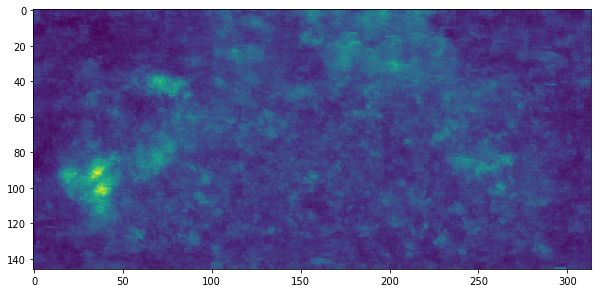

In [17]:
t=140
plt.figure(figsize=(10,10))
plt.imshow(np.nanmax(STA[t][:,:,:], axis=-1).T)

In [18]:
atlas = brainsss.load_roi_atlas()

In [19]:
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, atlas)

In [20]:
explosion_rois.keys()

dict_keys(['FB_group', 'ventromedial_r_group', 'ventromedial_l_group', 'PB', 'EB', 'anterior_group', 'dorsal_posterior_r_group', 'dorsal_posterior_l_group', 'MED_R', 'MED_L', 'LO_R', 'LO_L', 'LP_R', 'LP_L', 'AOTU_R', 'AOTU_L'])

In [21]:
explosion_rois['ventromedial_l_group']

{'rois': {58: 'AMMC_L', 60: 'VES_L', 80: 'GOR_L', 85: 'EPA_L'},
 'x_shift': 50,
 'y_shift': 55}

In [28]:
def moving_average_2d(arr, window_size=25):
    # Apply uniform filter to compute the moving average
    return uniform_filter(arr, size=window_size, mode='constant')

In [29]:
def sort_rows_by_max_index(arr):
    # Find the index of the maximum value in each row
    arr_avg=moving_average_2d(arr,window_size=5)
    max_indices = np.argmax(arr_avg, axis=1)
    
    # Get the sorted order of the rows based on the max indices
    sorted_order = np.argsort(max_indices)
    
    # Sort the rows of the array based on the sorted order
    sorted_arr = arr[sorted_order]
    return sorted_arr

In [30]:
%%time
total_vox_sorted={}
for area in explosion_rois:
    for key in explosion_rois[area]['rois']:
        area_name=explosion_rois[area]['rois'][key]
        if '_R' in area_name or '_L' in area_name:
            total_area_name=area_name.split('_')
            if len(total_area_name)==3:
                area_name=total_area_name[0]+'_'+total_area_name[1]
            else:
                area_name=total_area_name[0]
        roi=key
        roi_mask=roi_masks[roi]
        masked_roi=[STA[i][roi_mask] for i in range(np.shape(STA)[0])]
        masked_roi=np.transpose(masked_roi)
#         roi_sort=sort_rows_by_max_index(masked_roi)
        try:
            np.append(total_vox_sorted[area_name], masked_roi)
        except KeyError:
            total_vox_sorted[area_name]=masked_roi
for key in total_vox_sorted:
    total_vox_sorted[key]=sort_rows_by_max_index(total_vox_sorted[key])

CPU times: user 13.9 s, sys: 555 ms, total: 14.4 s
Wall time: 14.4 s


In [31]:
# to_include=list(total_vox_sorted.keys())[:5]
# subset_dict = {k: total_vox_sorted[k] for k in to_include}

In [215]:
step_10=np.array([[0.00006,-0.00002],[60,160]])
step_100=np.array([[0.003,-0.0001],[6,16]])

In [233]:
def plot_heatmap_area(areas_dict, area, ax, step_size):
    if step_size==10:
        stuff=step_10
    else:
        stuff=step_100
    ax.imshow(areas_dict[area], aspect='auto',vmax=stuff[0,0], vmin=stuff[0,1], cmap='plasma')
    ax.set_ylabel(area, rotation=0, labelpad=20)
    ax.axvline(x=stuff[1,0], ymin=0, ymax=1, ls='--', color='w', lw=5)
    ax.axvline(x=stuff[1,1], ymin=0, ymax=1, ls='--', color='w', lw=5)
    ax.set_yticks([])

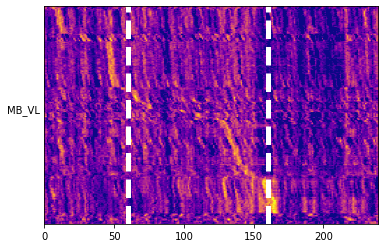

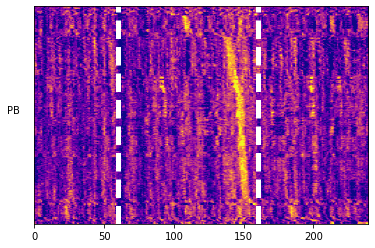

In [237]:
fig = plt.figure()
axs = fig.subplots()
plot_heatmap_area(total_vox_sorted, 'MB_VL', axs, step_size)
fig = plt.figure()
axs1 = fig.subplots()
plot_heatmap_area(total_vox_sorted, 'PB', axs1, step_size)

In [235]:
def plot_heatmap_allareas(areas_dict):
    num_areas=len(areas_dict)
    heights = [np.shape(areas_dict[key])[0] for key in areas_dict]
#     heights=[1/x for x in heights]
    fig = plt.figure(figsize=(5,10))
    gs = fig.add_gridspec(nrows=num_areas, ncols=1, height_ratios=heights, hspace=0)
    axs = gs.subplots(sharex='col', sharey=False)
    for i,key in enumerate(areas_dict):
        plot_heatmap_area(areas_dict, key, axs[i],step_size)
    for ax in axs:
        ax.label_outer()
#         ax.spines['top'].set_visible(False)
#         ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
#         ax.set_yticks([])
        
    plt.show()

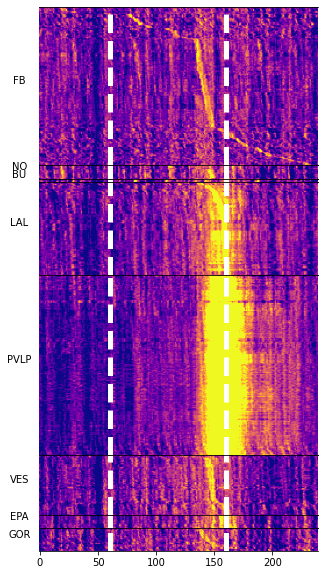

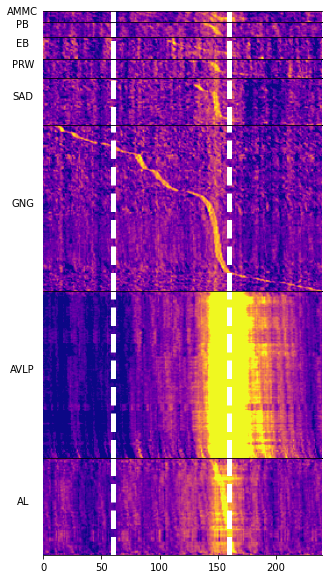

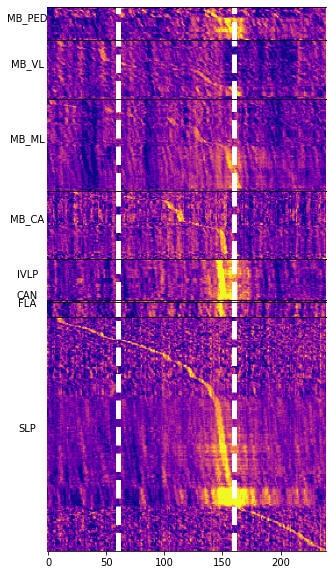

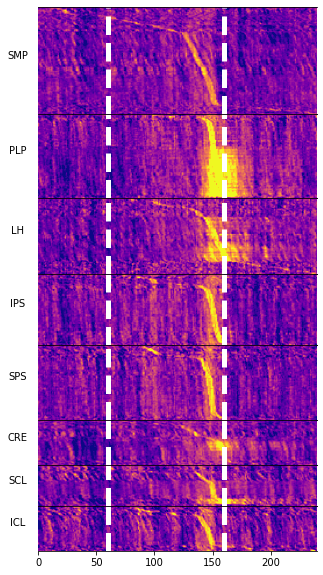

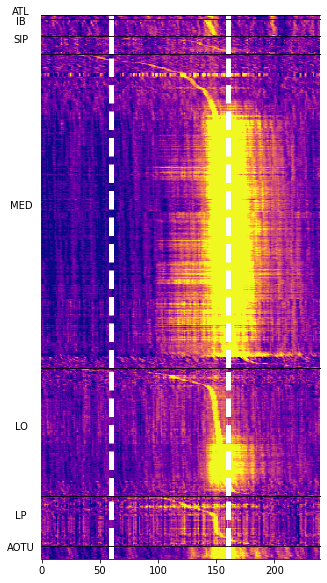

In [236]:
areas = int((len(total_vox_sorted)+1)/5)
for i in range(0,len(total_vox_sorted), areas):
    end = i + areas if i + areas < len(total_vox_sorted) else len(total_vox_sorted)
    sliced_keys = list(total_vox_sorted.keys())[i:end]
    sliced_dict = {k: total_vox_sorted[k] for k in sliced_keys if k in total_vox_sorted}
    plot_heatmap_allareas(sliced_dict)

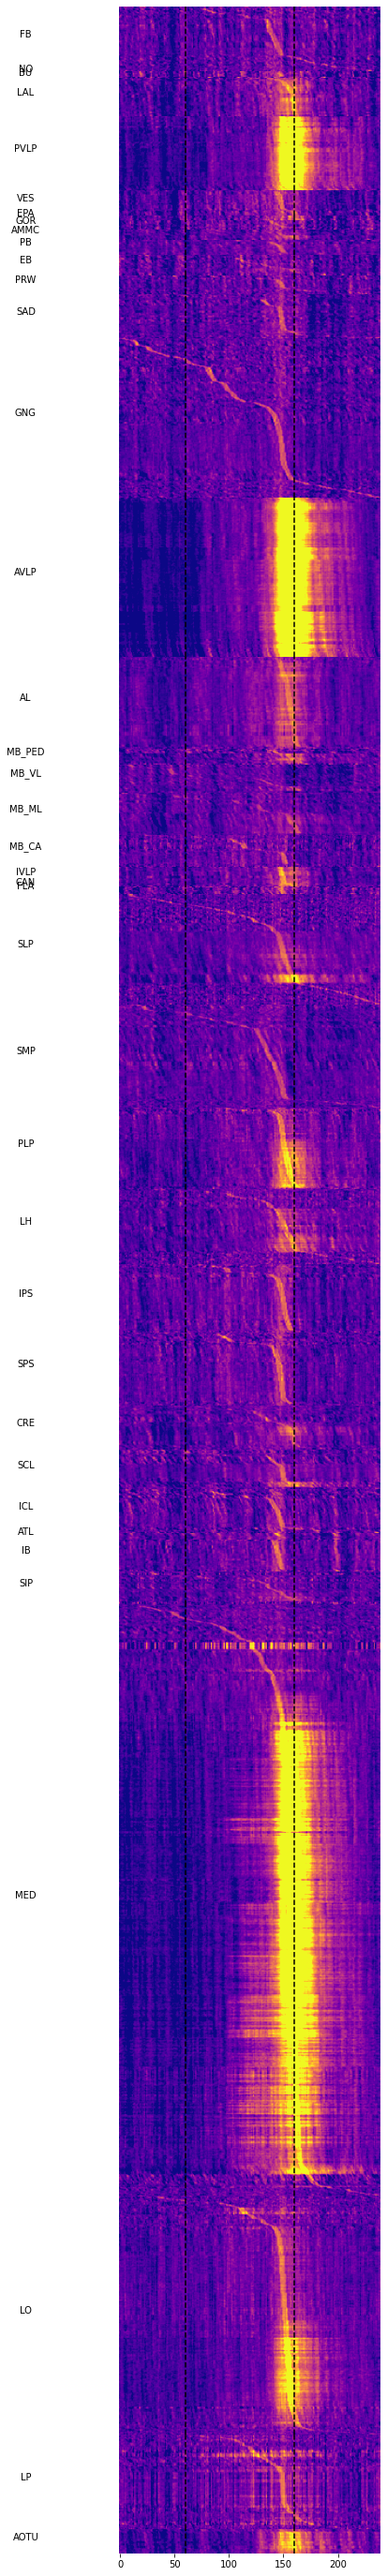

CPU times: user 13.1 s, sys: 1.58 s, total: 14.7 s
Wall time: 13.4 s


In [164]:
%%time
plot_heatmap_allareas(total_vox_sorted)

In [ ]:
%%time
explosions = []
for tp in range(np.shape(total_data_mean)[0]):
    input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
    data_to_plot = total_data_mean[tp][:,:,::-1]
    vmax = 0.005 #this was 0.5 for STA <------------
    explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                        roi_masks,
                                                        roi_contours,
                                                        data_to_plot,
                                                        input_canvas,
                                                        vmax=vmax,
                                                        cmap='seismic', diverging=True)#'hot')
    explosions.append(explosion_map)

In [ ]:
np.shape(explosions)

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(explosions[17][170:,:])

In [ ]:
movie_dir = os.path.join(later_dir, 'movies')
if os.path.exists(movie_dir)==False:
    os.mkdir(movie_dir)
print(movie_dir)

In [ ]:
save_dir = os.path.join(movie_dir,'dff_total')
if os.path.exists(save_dir)==False:
    os.mkdir(save_dir)
print(save_dir)

In [ ]:
plt.figure(figsize=(10,10))
for i in range(np.shape(total_data_mean)[0]):
    print(i)
    plt.imshow(explosions[i][170:,:]) #this was made with cmap=hot
    plt.axis('off')
    fname = os.path.join(save_dir, '{0:05d}.png'.format(i))
    plt.savefig(fname,dpi=300,bbox_inches='tight')